# Decision Tree Introduction

## Import Libraries

In [34]:
import numpy as np 
from sklearn.datasets import load_iris, make_moons
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from matplotlib.colors import ListedColormap
from graphviz import Source
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Training and Visualizing a Decision Tree

In [4]:
iris = load_iris(as_frame = True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

In [5]:
tree_clf = DecisionTreeClassifier(max_depth = 2 ,  random_state = 42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [6]:
export_graphviz(
    tree_clf, 
    out_file=  str(IMAGES_PATH/"iris_tree.dot"),
    feature_names = ["petal length (cm)", "petal width (cm)"],
    class_names = iris.target_names,
    rounded = True,
    filled = True
)

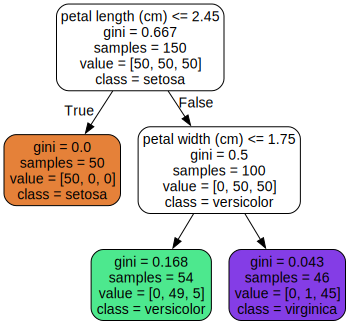

In [7]:
Source.from_file(IMAGES_PATH/"iris_tree.dot")

In [9]:
# extra code
!dot -Tpng {IMAGES_PATH / "iris_tree.dot"} -o {IMAGES_PATH / "iris_tree.png"}

## Making Prediction

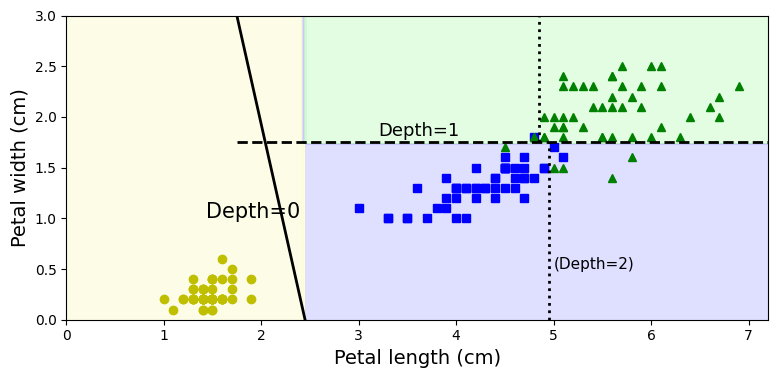

In [28]:
custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])
plt.figure(figsize=(8,4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha = 0.3, cmap = custom_cmap)

for idx, (name, style) in enumerate (zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:,0][y_iris == idx], X_iris[:,1][y_iris ==idx],
    style, label = f"Iris {name}")

tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state= 42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1,th2a, th2b,  = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th1], [0,3], "k-", linewidth = 2)
plt.plot([th1, 7.2], [th1, th1], "k--", linewidth = 2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth = 2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth = 2)

plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment = "right", fontsize = 15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment = "bottom", fontsize = 13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize = 11)
plt.axis([0, 7.2, 0, 3])

save_fig("decision_tree_decision_boundaries_plot")

In [30]:
# Access the tree structure via the tree_ attribute:
tree_clf.tree_

## Estimating Class Probablities

In [33]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [32]:
tree_clf.predict([[5, 1.5]])

array([1])

## Regularization Hyperparameters

In [37]:
X_moons, y_moons = make_moons(n_samples = 150, noise = 0.2, random_state= 42)

tree_clf1 = DecisionTreeClassifier(random_state= 42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf= 5, random_state =42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

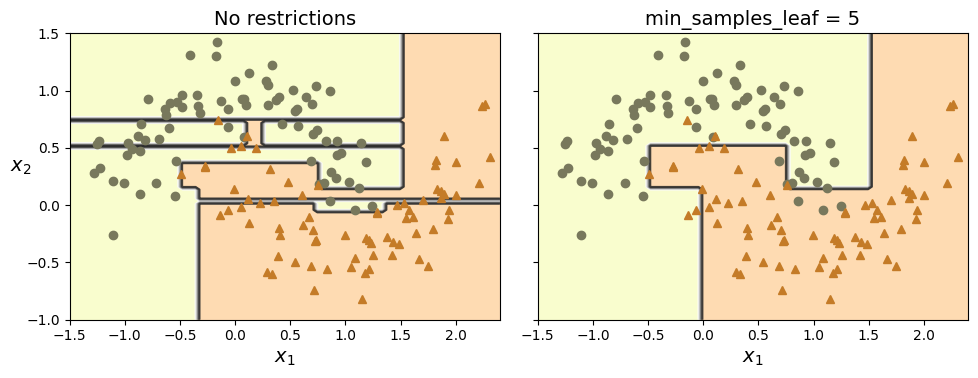

In [60]:
def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                        np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha = 0.3, cmap =cmap)
    plt.contour(x1, x2, y_pred, alpha = 0.8, cmap = "Greys")
    colors = {"Wistia" : ["#78785c", "#c47b27"], "Pastel1":["red", "blue"]}
    markers = ("o", "^")

    for idx in (0,1):
        plt.plot(X[:, 0][y == idx],  X[:,  1][y == idx],
                color = colors[cmap][idx],
                 marker = markers[idx], linestyle = "none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation = 0)

fig, axes = plt.subplots(ncols = 2, figsize = (10,4), sharey = True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons, 
                       axes =[-1.5, 2.4, -1, 1.5], cmap = "Wistia")
plt.title("No restrictions")

plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons, 
                       axes = [-1.5, 2.4, -1, 1.5], cmap = "Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
save_fig("min_samples_leaf_plot")

In [61]:
X_moons_test, y_moons_test = make_moons(n_samples =1000, noise = 0.2, random_state = 42)
tree_clf1.score(X_moons_test, y_moons_test)

0.901

In [62]:
tree_clf2.score(X_moons_test, y_moons_test)

0.918